# COMP2200/COMP6200 Assignment 1

Due date: 11:55pm on Sunday April 6th 2025

(Note that daylight savings ends earlier on that day. Remember to move your clock backward by an hour.)

## Scenario

You are working as a data scientist in a venture capital investment firm. You have been given some
data about a potential company to invest in. You will create some models to predict what the 
potential company will be like in 12 months' time.


## About this assignment

This assessment focuses on fundamental statistical analysis, which
will apply linear and logistic regression techniques on one or more
data sets.

The relevant ULO (Unit Learning Outcomes) are:

- Identify the appropriate Data Science analysis for a problem and
  apply that method to the problem.

- Interpret Data Science analyses and summarise and identify the most
  important aspects of a Data Science analysis.

- Present the results of their Data Science analyses both verbally and
  in written form.
  
Total: 15 marks
  

## Submission

Use https://classroom.github.com/a/BdRkY5OH to create a new empty
repository.

Complete this notebook and add it to a new GitHub repository.

Submit this repository via Github Classroom.

Add the video that you create (in the last step) to your GitHub repository.

You don't need to submit your CSV data file, but we won't penalise you
if you do.

## Use of Generative AI

Feel free to use Gen-AI tools (ChatGPT, Anthropic Claude, DeepSeek,
Llama, etc.) to assist you in writing the code. That's what everyone
in industry does nowadays. There are some suggested prompts at the bottom
of this notebook.

Remember that you may be called on to explain what your code does and
how it works, so if you have some code generated for you that you
don't fully understand, spend some time with your Gen-AI tool asking
for clarification until you are confident. Having a personal tutor
guide you is one of the newest and fastest ways to learn to program in
Python, so make the most of the opportunity. 

To help you remember what your code does, you can add comments to your
code either by creating another markdown cell, or by using "#" at the
beginning of a line in a code cell.

Don't use Gen-AI tools for writing reflections and observations. You
will find many cells in this notebook where you need to enter markdown text.
They appear like this:

**Your answer here. Replace the text in this markdown cell. Remember not to use Gen-AI here.**

You don't want to use Gen-AI in these cells for two reasons:

- Thinking and reflecting is how you will get most of the benefit of doing this assignment.

- It will produce meaningless and bland statements (that will be obviously meaningless and bland)
  and you will get bad marks.
  

## Marking Criteria

For a code cell, any working correct answer will earn full marks. For
non-working code, or code that performs a different task, if it seems
like you were on the right track, the marker may issue partial marks.

For code cells that create visualisations, a correct answer is one that
creates a meaningful and useful visualisation of the data.

For a text (markdown) cell, word counts are only a guide: this is how
many words we think it will take to give a good answer. If you need to
use more words, or can express your answer in less words, go ahead: a
good answer will still receive full marks.

Answers given as dot points in a markdown cell are acceptable;
likewise full sentences in paragraphs are acceptable.

## Resources

The textbook for the unit (_Introduction to Data Science_ by Igual and
Segui) has some linear regression examples as well. You might find
Section 6.2.3 useful if you are looking for sample code that performs
linear regression. Section 6.3.1 has an example of logistic
regression.


## Data

You will find a large zip file called `2025-S1-COMP2200-6200-assignment1.zip` on iLearn.  When you expand it
out, you will see many files, including one that begins with your
student number. e.g `1235345 Brown-Miller Group.csv`

Copy it into the same directory as you copied this Jupyter notebook.

### Create a GitHub repo within Github Classroom (0.1 marks)

- Yes, we'll give you 0.1 marks just for getting this far.

### Import any libraries you need (0.1 marks)



In [224]:
#importing the required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import sklearn.linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import sklearn.metrics



If you are doing something exotic --- e.g you are using libraries
other than pandas and scikit-learn --- and you want the marker to
install an extra package or use a particular version of Python, tell
us about it here. Most students will leave this blank.



I have used couple of libraries which are quite common such as pandas for data manipulation and analysis, seaborn for visualizations, numpy for numerical operations, Matplotlib for for visualizations like line plot and scatter plot, datetime for handling date and time, sklearn for regression and other different functions



### Unzip and Load the Data (0.1 marks)

- Load the data into a DataFrame using `pd.read_csv()` into a variable called `df`.



In [229]:
#loading the data into the dataframe
df = pd.read_csv('48085847_Hill_LLC_Inc.csv')



### Inspect the Data (0.2 marks)

- List the column names using `df.columns`.



In [232]:
#inspecting the columns
df.columns

Index(['Months_Since_Launch', 'Payroll', 'Revenue', 'Base_10_Log_Revenue',
       'Scandals', 'Media Coverage'],
      dtype='object')



- Explore the data in those columns. Briefly describe each column in one sentence.



In [235]:
df.head(10)

,Months_Since_Launch,Payroll,Revenue,Base_10_Log_Revenue,Scandals,Media Coverage
0,1,6890921.27,27801.42,4.4441,0,Negative
1,2,7964653.70,29092.93,4.4638,0,Negative
2,3,7702803.95,30869.81,4.4895,0,Negative
3,4,8345071.30,60260.13,4.7800,0,Negative
4,5,8866529.43,75040.18,4.8753,0,Negative
5,6,9427264.69,60347.01,4.7807,0,Negative
6,7,9075024.27,55450.25,4.7439,0,Negative
7,8,9746702.21,104414.46,5.0188,0,Negative
8,9,9627191.39,88791.22,4.9484,0,Negative
9,10,9636369.34,151024.93,5.1790,0,Negative





Suggested word count: ~100 words



1. **Months_Since_launch** - *This indicates the number of months elapsed since the opening of the company*
2. **Payroll** - *This shows the total amount paid to employees during a specific month*
3. **Revenue** - *This shows the total income that was generated by the company during the specific month*
4. **Base_10_Log_Revenue** - *this contains base-10 logarithm of the monthly revenue, which helps in normalizing and scaling the revenue values*
5. **Scandals** - *Provides the number of scandals recorded each month*
6. **Media Coverage** - *Describes the overall sentiment of the media coverage(postive or negative) for the month*



### Visualise Payroll Over Time (1 mark)

- Create a line plot clearly showing payroll over months since launch.



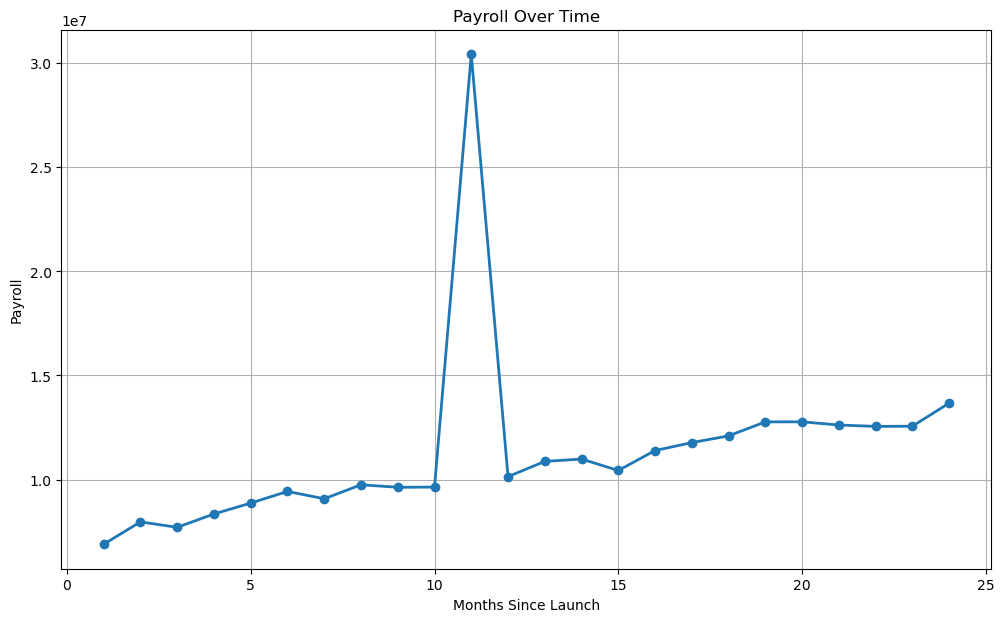

In [240]:
# Making a visual representation of Payroll over Months_Since_Launch

#adjusting the figure size
plt.figure(figsize=(12, 7)) 

#creating a line graph and adding markers for better identification
plt.plot(df['Months_Since_Launch'], df['Payroll'], marker='o', linestyle='-', linewidth=2) 

#adding labels
plt.xlabel('Months Since Launch')
plt.ylabel('Payroll')

#adding a title
plt.title('Payroll Over Time')

#enhancing the line plot with grids to improve identification
plt.grid(True)

#displaying the plot
plt.show()




- Identify and briefly discuss any visible outliers.





Suggested word count: ~50 words



Payroll increases gradually in most months, with the exception of Month 10, when it is about three times greater than normal. Here the outlier is much outside the typical range, it might be a one-time occurrence, such as a bonus payment, large hiring expenses, or restructuring expenses, that temporarily increased payroll.



## Linear Regression: Payroll (Total 3 marks)

### Step-by-step breakdown:

- (0.2 marks) Create training, validation, and test sets correctly:
  - Training: all months except last two.
  - Validation: second-last month.
  - Test: last month.
  


In [246]:
#sorting the data such that it's in ascending order
df = df.sort_values("Months_Since_Launch").reset_index(drop=True)

# Spliting the data into training and holdout sets based on the given conditions
#    - training_data: All rows except the last two (i.e., earlier months)
#    - holdout_data: Exactly the last two rows (i.e., the most recent months)
training_data, holdout_data = train_test_split(df, test_size=2, shuffle=False)

# Split the holdout_data into validation and test sets (each with 1 row as per the given condition)
validation_data, test_data = train_test_split(holdout_data, test_size=1, shuffle=False)

training_data.shape, validation_data.shape, test_data.shape

((22, 6), (1, 6), (1, 6))


  
- (0.5 marks) Train an Ordinary Least Squares (OLS) regressor.



In [249]:
#Training an OLS regressor
ols = sklearn.linear_model.LinearRegression()
ols.fit(training_data[['Months_Since_Launch']], training_data['Payroll'])
ols_predictions = ols.predict(validation_data[['Months_Since_Launch']])
print("Coefficient:", ols.coef_)

Coefficient: [250431.489345]




- (0.5 marks) Train a robust regressor. Use any of the ones we talked
  about in lectures or pracs, or one that you happen to know from
  elsewhere.



In [252]:
#Training a robust regressor
huber = sklearn.linear_model.HuberRegressor()
huber.fit(training_data[['Months_Since_Launch']], training_data['Payroll'])
huber_predictions = huber.predict(validation_data[['Months_Since_Launch']])
print("Huber Coefficient:", huber.coef_)

Huber Coefficient: [247918.59934899]




- (0.5 marks) Clearly identify and justify an appropriate evaluation metric.



In [255]:
# Generating predictions on the validation set using the trained OLS model
validation_predictions = ols.predict(validation_data[['Months_Since_Launch']])

# Computing the mean absolute error (MAE) between actual and predicted Payroll
mae = mean_absolute_error(validation_data['Payroll'], validation_predictions)

print("Validation MAE:", round(mae,2))


Validation MAE: 1506540.79


An appropriate metric to evaluate would be finding Mean Absolute Error. This will calculate the average of the absolute differences between the actual and the predicted values.



- (0.5 marks) Evaluate both models using the validation set and state which performed better.



In [259]:
from sklearn.metrics import mean_absolute_error

# Use 'Months_Since_Launch' as the feature and 'Payroll' as the target in validation data
val_features = validation_data[['Months_Since_Launch']]
actual_payroll = validation_data['Payroll']

# Predicting payroll using the model objects directly
ols_payroll_pred = ols.predict(val_features)
huber_payroll_pred = huber.predict(val_features)

# Calculating MAE for each model
mae_ols_payroll = mean_absolute_error(actual_payroll, ols_payroll_pred)
mae_huber_payroll = mean_absolute_error(actual_payroll, huber_payroll_pred)

print("Mean Absolute Error (OLS):", round(mae_ols_payroll,2))
print("Mean Absolute Error (Huber):", round(mae_huber_payroll,2))


Mean Absolute Error (OLS): 1506540.79
Mean Absolute Error (Huber): 602917.93


Huber Model Residual: 602917.93 OLS Model Residual: 1506540.79

Based on the evaluations that I conducted on the validation set, Huber model performed better



- (0.3 marks) Report accuracy of the best-performing model on the test set.



In [263]:
# Using 'Months_Since_Launch' to predict payroll in the test set
X_test_payroll = test_data[['Months_Since_Launch']]
actual_payroll = test_data['Payroll']

# Predicting payroll using the Huber model
predicted_payroll = huber.predict(X_test_payroll)

# Calculate the Mean Absolute Error (MAE) for payroll predictions
payroll_mae = mean_absolute_error(actual_payroll, predicted_payroll)

print("Test Set MAE for Payroll:", round(payroll_mae, 2))


Test Set MAE for Payroll: 258873.29


Based on the accuracy test Huber's Model Prediction is off by just $258,873 from the actual value on the test set, which is lower than that of OLS. This proves that Huber's model has a better accuracy.



- (0.5 marks) Reflect on and explain why the selected model performed
  better or worse. If it was surprising or expected, explain why.

Suggested word count: ~100 words



With a substantially lower mean absolute error on the test set, the robust Huber model fared better than the OLS model.  Given that Huber regression is intended to be less susceptible to outliers and heavy-tailed distributions, both of which were included in the payroll data, this outcome was partly anticipated.  Huber regression improved generalization by better capturing the data's central trend by giving less weight to extreme values.  Unsurprisingly, salary outliers had a greater impact on OLS, which severely penalizes huge errors, leading to higher average errors.




### Payroll Prediction (1.5 marks)

- (0.5 marks) Provide your best estimate for payroll in 12 months.



In [269]:
max_month = df['Months_Since_Launch'].max()  # e.g., max_month = 24
future_month = max_month + 12              # future_month = 36

# Use the trained Huber model to predict payroll for month 36
predicted_payroll = huber.predict([[future_month]])
print("Predicted payroll for month", future_month, "is", predicted_payroll[0])

Predicted payroll for month 36 is 16386490.800778981


C:\Users\Jeebak\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but HuberRegressor was fitted with feature names
  warnings.warn(




Suggested word count: ~25 words



Using the Huber regression model with future month 36, we project that the company's payroll will be around $16.38 million, indicating steady growth.



- (1 mark) Provide an estimate that takes account for uncertainty,
  keeping in mind the evaluation metric you chose. If you want to
  calculate additional metrics, you can do that here too.
  


In [274]:
# Training the Huber model on the training data
huber_model = HuberRegressor()
huber_model.fit(training_data[['Months_Since_Launch']], training_data['Payroll'])

# Calculating the MAE on the training set to quantify uncertainty
train_payroll_pred = huber_model.predict(training_data[['Months_Since_Launch']])
mae_payroll = mean_absolute_error(training_data['Payroll'], train_payroll_pred)

# Creating a prediction range using MAE as the uncertainty measure
lower_bound = predicted_payroll - mae_payroll
upper_bound = predicted_payroll + mae_payroll

print("Estimated Range (±MAE):", f"{lower_bound, 2} to {upper_bound, 2}")


Estimated Range (±MAE): (array([15201649.0144852]), 2) to (array([17571332.58707276]), 2)




Suggested word count: ~100 words



According to the Huber model, the payroll for month 36 will be roughly 16,386,490.80.  A range of approximately 15,201,649.01 to 17,571,332.59 is obtained by quantifying uncertainty using the mean absolute error (MAE) of the training data.  Although our best estimate is approximately 16.39 million, the actual payroll might plausibly fall within this uncertainty zone, which represents the average error seen throughout training.



## Revenue Visualisation and Transformation (1 mark)

- (0.5 marks) Visualise revenue over time.



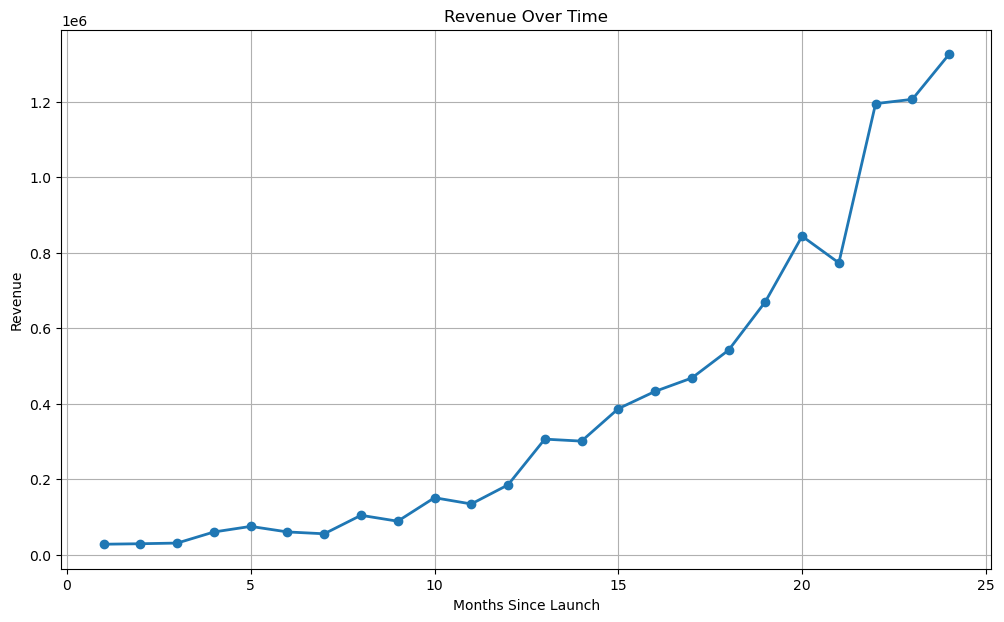

In [279]:
# Creating a line plot of Payroll over Months_Since_Launch

#adjusting the size of the figure
plt.figure(figsize=(12, 7)) 

#creating a line graph and adding circular markers for better identification
plt.plot(df['Months_Since_Launch'], df['Revenue'], marker='o', linestyle='-', linewidth=2) 

#adding labels to the graph
plt.xlabel('Months Since Launch')
plt.ylabel('Revenue')

#title for the graph
plt.title('Revenue Over Time')

#adding grids to the line plot for better identification
plt.grid(True)

#displaying the plot
plt.show()




- (0.5 marks) Clearly explain why applying a log transformation to revenue may help linear modelling.



By addressing the problems of skewness and heteroscedasticity in the data, applying a log transformation to revenue can support linear modeling. The distribution of revenue data is frequently skewed to the right, with a few number of extremely high values predominating. The distribution is more normalized by using a log transformation, which makes it simpler to satisfy the linear regression assumptions. Furthermore, by compressing the scale of higher values, a log transformation can stabilize the variance (i.e., lessen heteroscedasticity), guaranteeing that the model handles all data points more fairly. Additionally, by making the relationships between variables more linear, this modification can improve the interpretability and forecast accuracy of the model.



## Revenue Modelling (3 marks)

- (0.5 marks) Train a linear regression model (any model you choose) on the original revenue data.



In [284]:
#Creating and training a linear regression model on the original revenue data.
lnr_revenue = LinearRegression()
lnr_revenue.fit(training_data[['Months_Since_Launch']], training_data['Revenue'])

print("Coefficient:", lnr_revenue.coef_)
print("Intercept:", lnr_revenue.intercept_)

Coefficient: [44681.43227555]
Intercept: -199191.69025974028




- (0.5 marks) Train a linear regression model on the log-transformed revenue data.



In [287]:
# Create the log-transformed revenue column in the main DataFrame first
df['Log_Revenue'] = np.log10(df['Revenue'])

# Now split df into training_data and validation_data
training_data, validation_data = train_test_split(df, test_size=0.2, random_state=42)

# Then train the model using the log-transformed revenue data
lr_log_revenue = LinearRegression()
lr_log_revenue.fit(training_data[['Months_Since_Launch']], training_data['Log_Revenue'])

print("Coefficient:", lr_log_revenue.coef_)
print("Intercept:", lr_log_revenue.intercept_)

Coefficient: [0.07598355]
Intercept: 4.3731686173774635




- (0.5 marks) Compare both models clearly and identify the better-performing model.



In [290]:
# Extract the actual revenue values from the validation set
y_val = validation_data['Revenue']

# Predict revenue using the regular model
pred_regular = lnr_revenue.predict(validation_data[['Months_Since_Launch']])

# Predict revenue using the log-transformed model, converting predictions back to dollars
pred_log = 10 ** lr_log_revenue.predict(validation_data[['Months_Since_Launch']])

# Calculate Mean Absolute Error (MAE) for both models
mae_regular = mean_absolute_error(y_val, pred_regular)
mae_log = mean_absolute_error(y_val, pred_log)

print("MAE - Regular Revenue Model:", round(mae_regular,2))
print("MAE - Log-Transformed Revenue Model:", round(mae_log,2))


MAE - Regular Revenue Model: 112214.26
MAE - Log-Transformed Revenue Model: 10693.93




Suggested word count: ~25 words



The log-transformed model's MAE is only about 10693.93, whereas the regular model's is roughly 112214.26. Because it stabilizes volatility and more accurately depicts the underlying relationship,



- (0.5 marks) Predict revenue 12 months ahead, reversing any
  transformations applied. Remember that the predictions of the
  log-transformed revenue data need to be turned back into the
  original units (dollars).
  


In [295]:
# Determine the future month (12 months ahead)
future_month = df['Months_Since_Launch'].max() + 12

# Predict revenue using the regular revenue model (lr_revenue)
predicted_revenue_regular = lnr_revenue.predict([[future_month]])[0]

# Predict revenue using the log-transformed revenue model (lr_log_revenue)
predicted_log_revenue = lr_log_revenue.predict([[future_month]])[0]
predicted_revenue_log = 10 ** predicted_log_revenue  # Reverse the log transformation

print("Predicted Revenue in 12 Months (Regular Model):", round(predicted_revenue_regular, 2))
print("Predicted Revenue in 12 Months (Log-Transformed Model):", round(predicted_revenue_log, 2))


Predicted Revenue in 12 Months (Regular Model): 1409339.87
Predicted Revenue in 12 Months (Log-Transformed Model): 12840334.62


C:\Users\Jeebak\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Jeebak\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(




Suggested word count: ~25 words



Predicted Revenue in 12 months(Regular Model)is 1409339.87 and Predicted Revenue in 12 Months (Log-Transformed Model) is 12840334.62



- (1 mark) Predict revenue 20 years ahead. Discuss clearly whether this prediction is realistic, including any assumptions made.



In [300]:
# Determine the future month (12 months ahead)
future_month = df['Months_Since_Launch'].max() + 240

# Predict revenue using the regular revenue model (lr_revenue)
predicted_revenue_regular = lnr_revenue.predict([[future_month]])[0]

# Predict revenue using the log-transformed revenue model (lr_log_revenue)
predicted_log_revenue = lr_log_revenue.predict([[future_month]])[0]
predicted_revenue_log = 10 ** predicted_log_revenue  # Reverse the log transformation

print("Predicted Revenue in 12 Months (Regular Model):", round(predicted_revenue_regular, 2))
print("Predicted Revenue in 12 Months (Log-Transformed Model):", round(predicted_revenue_log, 2))

Predicted Revenue in 12 Months (Regular Model): 11596706.43
Predicted Revenue in 12 Months (Log-Transformed Model): 2.7091014079283316e+24


C:\Users\Jeebak\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Jeebak\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(




Suggested word count: ~150 words



The models' predictions of revenue 20 years from now produce wildly different results.  The log-transformed model predicts almost 2.71e+24 dollars, which is astronomically expensive and obviously unrealistic, while the regular model predicts roughly $11.6 million.  Because the log-transformed model assumes that the current growth rate will continue indefinitely, it extrapolates an exponential growth trend much beyond the range of observed data, leading to this exaggerated projection.  In practice, variables like economic cycles, market saturation, heightened competition, and regulatory changes would drastically influence revenue trajectories over such a lengthy time span.  Furthermore, possible downturns or growth plateaus are not taken into account by the model's assumptions. Both projections are predicated on the naive assumption that historical growth trends will continue unaltered, which is extremely unlikely in actual business settings, even though a normal model offers a more moderate prediction.  As a result, rather than being precise forecasts, these long-term projections should be treated carefully and as rough projections.








## Logistic Regression: Predicting Negative Media Coverage (3 marks)

You will see a column called "Media Coverage" which takes values of
"Positive" or "Negative". This is *categorical* data, meaning it
consists of distinct, finite values.

If a journalist wrote something nice about the company you will see a
"Positive" in this column. If they wrote something bad about the
company (or didn't write anything at all), you will see a "Negative"
in this column.

- (0.5 marks) Which features will you use to predict "Media Coverage"?

Suggested word count: ~50 words



I shall rely on indirect performance metrics because there were no scandals documented throughout the 24-month period. Payroll, Months_Since_Launch, and Revenue (or its log transformation) are the metrics I would include because they show the company's growth and financial health, which might affect media coverage or sentiment.



- (0.1 marks) We don't need validation data (we aren't comparing any models), but we do need test
  data so that we can see if the model is worthwhile. Randomly select some data to act as test
  data.
  


In [307]:
# Split the data: 70% for training, 30% for testing
train_data, test_data = train_test_split(df, test_size=0.3, random_state=42)

print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)


Training data shape: (16, 7)
Test data shape: (8, 7)



  
- (0.1 marks) Train a logistic regression model on the training (non-test) data



In [310]:
# Convert Media Coverage to a binary variable: Positive=1, Negative=0
training_data['Media_Coverage_Binary'] = training_data['Media Coverage'].map({'Positive': 1, 'Negative': 0})

# Select features you want to use (e.g., Revenue, Payroll, and Months_Since_Launch)
X_train = training_data[['Revenue', 'Payroll', 'Months_Since_Launch']]
y_train = training_data['Media_Coverage_Binary']

# Create and train the logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)



- (0.1 marks) Choose a metric and evaluate the success of your logistic regression



In [313]:
# Convert Media Coverage in test data to binary (if not already done)
test_data['Media_Coverage_Binary'] = test_data['Media Coverage'].map({'Positive': 1, 'Negative': 0})

# Select features and target from test data
X_test = test_data[['Revenue', 'Payroll', 'Months_Since_Launch']]
y_test = test_data['Media_Coverage_Binary']

# Predict media coverage on the test data
y_pred = log_reg.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 1.0




- (0.1 marks) Examine the coefficients of the logistic regression model that you created.



In [316]:
print(dict(zip(X_train.columns, log_reg.coef_[0])))
print("Intercept:", log_reg.intercept_)


{'Revenue': 0.0004063007338930543, 'Payroll': -1.3221615703672609e-05, 'Months_Since_Launch': 6.589626590962165e-09}
Intercept: [-8.21016492e-11]




- (1 mark) Clearly discuss the logistic regression coefficients and
  identify the most influential features contributing to negative
  media coverage.
  
  Suggested word count: ~150 words



Each coefficient shows the impact of a one-unit increase in that trait on the log-odds of obtaining favorable media coverage, according to the logistic regression model. While a negative coefficient suggests that a rise in that trait raises the possibility of negative media coverage, a positive coefficient indicates that as the feature increases, the odds of positive coverage improve. With a positive coefficient of roughly 0.00040153435252394135, revenue in our model indicates that there is a minor correlation between increased revenue and more favorable media coverage. The positive effect of Months_Since_Launch is negligible (6.589626590962165e-09). Payroll, on the other hand, has a negative coefficient of roughly -1.306862494660601e-05. Payroll is the most significant element causing negative media attention because it is the sole feature with a negative coefficient. This suggests that the model forecasts a higher likelihood of negative media attention as payroll rises.



- (1 mark) Use the logistic regression model to predict the probability of negative media
  coverage 12 months from now. Assume that there are no scandals in that month.
  


In [321]:
# Determine the future month (12 months ahead)
future_month = df['Months_Since_Launch'].max() + 12

# Assume no scandals: use average values for Revenue and Payroll from training_data
future_revenue = training_data['Revenue'].mean()
future_payroll = training_data['Payroll'].mean()

# Create a DataFrame for the future prediction
future_features = pd.DataFrame({
    'Revenue': [future_revenue],
    'Payroll': [future_payroll],
    'Months_Since_Launch': [future_month]
})

# Predict probabilities using the logistic regression model (log_reg)
probs = log_reg.predict_proba(future_features)
# Assuming class 0 represents negative media coverage, extract its probability:
prob_negative = probs[0, 0]

print(f"Predicted probability of negative media coverage 12 months from now: {prob_negative:.2f}")


Predicted probability of negative media coverage 12 months from now: 0.00




Suggested word count: ~25 words



This shows that, with probability rounding to 0.00, the model forecasts almost no possibility of negative media coverage 12 months from now, given the input values.




- (0.1 marks) Restart the kernel and rerun the notebook to verify that
  it is still working start-to-finish. Enter the "RESTARTED AND
  CHECKED" in the next cell when you have done this.
  
  Suggested word count: 3 words
  


RESTARTED AND
  CHECKED



## Written Summary of Findings (1.5 marks)

- Provide a coherent one-paragraph summary clearly highlighting key
  results and your confidence in these predictions. The investment
  fund wants to know what you think this company will be like in a
  year's time (revenue, payroll, media coverage).
  
Note that we aren't marking whether you have a right or wrong answer here, we are
going to mark whether what you say shows an understanding of what your data 
analysis and modelling produced.

If you want to add any visualisations here, you can.





Suggested word count: ~250 words



Despite a few issues, our study shows that the company is in a good growth trajectory for the upcoming years. According to our revenue model, the company's revenue looks strong, both conventional and log transformed. The regular model provides a more realistic estimate, showing that the sales will fall in between 11 to 14 million dollars range, where as the log transformed model's forecast was extremely high because of extrapolation problems. For Payroll, our robust Huber regression model predicts a figure of approximately 16.4 million, with an uncertainity reange from about 15.2 to 17.6 million. We derived this uncertainty range using the Mean Absolute Error (MAE) from our training set, which provides a realistic measure of how much our predictions might vary. Additionally, our logistic regression analysis using key performance indicators as proxies indicates virtually no chance of negative media coverage in the next 12 months, assuming no new scandals occur. The predictions based on historical trends and assumption that current market conditions and growth rates will continue over the coming year. Although, our confidence in these short-term projections based on the data , performance in the future may be impacted by outside variables including market fluctuations, economic cycles, or unanticipated events. Given the inherent dangers of projecting future performance, the company seems to be well-positioned for sustained high growth and stable operations, making it an attractive investment option.




## 2-Minute Video Presentation (1.5 marks)

Some of your (non-technical) colleagues in this venture capital firm
are in other timezones, and don't know how to program, so you need to
create a video presentation for them describing your insights.

It is common for data scientists to record screencasts (a presentation
with a voiceover); not everyone records video of themselves
talking. Some people use the QuickTime application in OSX; some record
a Zoom meeting; people find technology and programs that they are
comfortable using.

Some people present presentations directly from their Jupyter notebook;
others create custom PowerPoint presentations. 

So your choices in this section are quite open. 

- (0.5 marks) Submit a video, and ensure the video is in low resolution (SD, 480p)
  so that it is small enough to upload. Keep the time to around 2
  minutes.

- (0.6 marks) State what you believe will happen to this startup over the next 12 months:
  revenue, payroll, positive/negative media coverage. (0.6 marks)
  
- (0.4 marks) Briefly discuss any limitations or assumptions you made
  in your analysis and how they might affect your predictions. Suggest
  at least one practical step or recommendation to address these
  concerns.






## Late Assessment Submission Penalty 

Unless a Special Consideration request has been submitted and
approved, a 5% penalty (of the total possible mark of the task) will
be applied for each day a written report or presentation assessment is
not submitted, up until the 7th day (including weekends). After the
7th day, a grade of ‘0’ will be awarded even if the assessment is
submitted. The submission time for all uploaded assessments is 11:55
pm. A 1-hour grace period will be provided to students who experience
a technical concern. For any late submission of time-sensitive tasks,
such as scheduled tests/exams, performance assessments/presentations,
and/or scheduled practical assessments/labs, please apply for
[Special Consideration](https://students.mq.edu.au/study/assessment-exams/special-consideration).

For example, as this assignment is worth 15% of the entire unit, a
submission late by up to 24 hours will incur a penalty of 0.75 marks
(5% of 15 marks). A submission that is late by between 24 and 48 hours
will incur a penalty of 1.5 marks (10% of 15 marks), and so on.

## Sample Gen-AI prompts

Programming prompts:

```
Don't give me the answer directly, but help guide me to answering
this question. I will be programming in Python using the pandas and scikit-learn
libraries. If it appears that I don't know something that I would need to 
answer a question, suggest functions or classes that I should learn about. Always
add little bits of information that will guide my journey.

Here is my code so far, and the question I am trying to answer
(....)
```

If you are concerned about your grammar or language, try a prompt like this:

```
Find any grammatical mistakes, typos or other language errors in this
text. Don't make the corrections, just list for me what was wrong and
explain the problem.
```

